[1] Dados obtidos com sucesso através da API do IBGE.
Indicador: Economia - PIB per capita
País: Brasil

[2] Série histórica carregada.
Quantidade de observações: 26
Primeiro ano: 1990
Último ano: 2023

Primeiros registros:
    ano  pib_per_capita
0  1990         3117.74
1  1995         4756.75
2  2000         3766.55
3  2001         3176.29
4  2002         2855.94


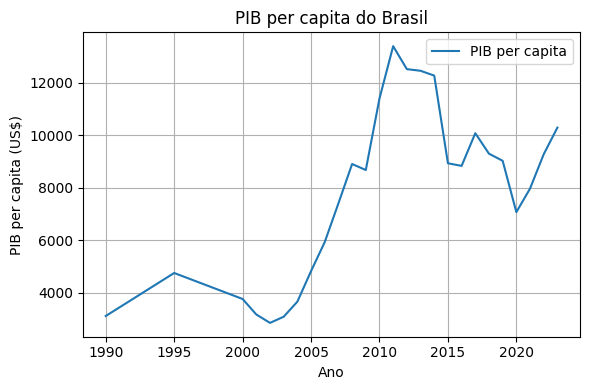

[3] Série temporal criada.
Quantidade de valores: 26

[4] Janelas temporais criadas.
X: (21, 5)
y: (21,)

[5] Divisão treino/teste:
X treino: (16, 5)
X teste: (5, 5)
y treino: (16,)
y teste: (5,)

[6] Dados normalizados.
X treino normalizado: (16, 5)

[7] Formato final para a LSTM:
X treino: (16, 5, 1)
X teste: (5, 5, 1)

[8] Arquitetura da LSTM:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 640ms/step - loss: 0.4101 - mae: 0.5418 - val_loss: 0.3431 - val_mae: 0.5837
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - loss: 0.3963 - mae: 0.5323 - val_loss: 0.3259 - val_mae: 0.5687
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.3876 - mae: 0.5265 - val_loss: 0.3175 - val_mae: 0.5612
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.3821 - mae: 0.5225 - val_loss: 0.3103 - val_mae: 0.5548
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.3765 - mae: 0.5183 - val_loss: 0.3028 - val_mae: 0.5480
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.3705 - mae: 0.5139 - val_loss: 0.2951 - val_mae: 0.5409
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.3643 - mae: 0.5093 - val_loss: 0.2872 - val_mae: 0.5335
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.3580 - mae: 0.5044 - val_loss: 0.2782 - val_mae: 0.5250
Epoch 9/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.

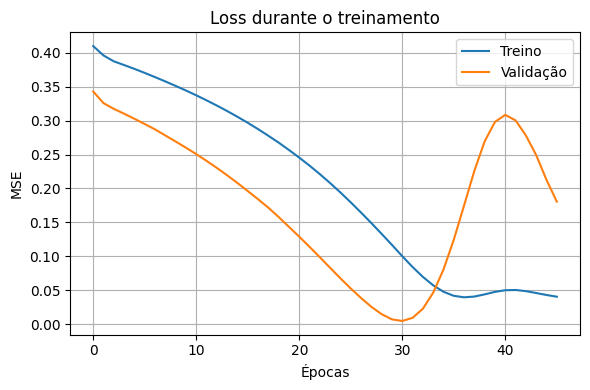

[10] Previsões realizadas.
Formato das previsões: (5, 1)

[11] Avaliação da LSTM:
MSE = 1,691,276.10
MAE = US$ 1,064.87


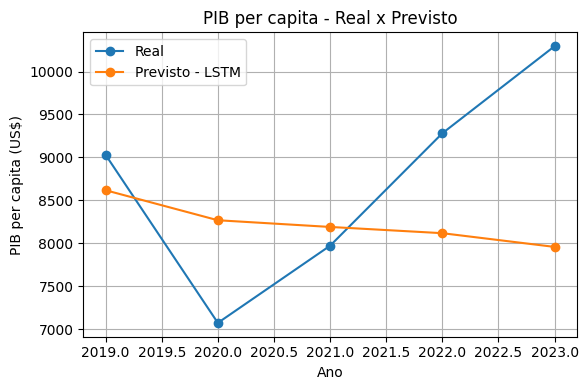


[12] Baseline Naive:
MSE = 1,842,938.78
MAE = US$ 1,294.08

[13] Comparação dos modelos:


,Modelo,MSE,MAE
0,Baseline Naive,1.842939e+06,1294.08000
1,LSTM,1.691276e+06,1064.87416


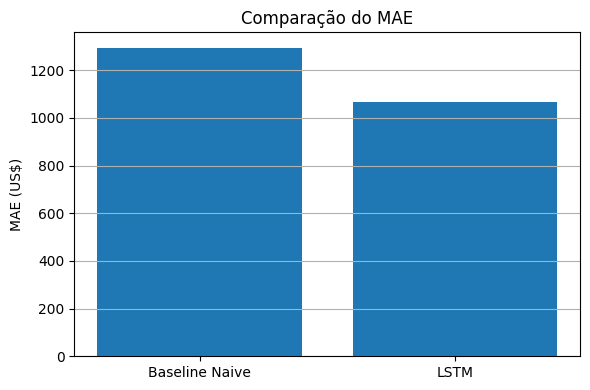


RESUMO FINAL DO PROJETO
Indicador: PIB per capita do Brasil
Período: 1990 - 2023
Tamanho da janela: 5 anos

LSTM:
  MSE = 1,691,276.10
  MAE = US$ 1,064.87

Baseline Naive:
  MSE = 1,842,938.78
  MAE = US$ 1,294.08


In [1]:
"""
Projeto - Previsão de Série Temporal com LSTM
PIB per capita do Brasil - API do IBGE
"""

# ---------------------------------------------------------------------------
# Descrição do projeto
# ---------------------------------------------------------------------------
#
# O objetivo deste projeto é utilizar dados históricos do PIB per capita
# do Brasil, obtidos através da API pública do IBGE, para realizar uma
# previsão de séries temporais utilizando uma rede neural LSTM.
#
# Será utilizada uma janela de 5 anos para prever o valor do ano seguinte.
#
# Exemplo:
#
# 2010 2011 2012 2013 2014 -> 2015
# 2011 2012 2013 2014 2015 -> 2016
# 2012 2013 2014 2015 2016 -> 2017
#
# Os dados serão divididos respeitando a ordem cronológica, sem
# embaralhamento, para evitar vazamento de informações do futuro.
#
# O MinMaxScaler será utilizado para normalizar os dados.
#
# A rede neural utilizada será uma LSTM com:
#
# LSTM(32) -> Dense(16) -> Dense(1)
#
# A avaliação será realizada através das métricas MSE e MAE.
#
# Ao final, os valores serão desnormalizados para que o MAE possa
# ser interpretado na escala original do PIB per capita.
#
# será utilizado um Baseline Naive para
# comparação com a LSTM.


# ---------------------------------------------------------------------------
# PARTE B — Prática
# ---------------------------------------------------------------------------

import numpy as np
import pandas as pd
import tensorflow as tf
import requests
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


tf.random.set_seed(42)
np.random.seed(42)


# ---------------------------------------------------------------------------
# 1) Coleta dos dados através da API do IBGE
# ---------------------------------------------------------------------------

url = "https://servicodados.ibge.gov.br/api/v1/paises/BR/indicadores/77823"

resposta = requests.get(url)

if resposta.status_code != 200:
    raise Exception(
        f"Erro ao acessar a API do IBGE: {resposta.status_code}"
    )

dados = resposta.json()

print("[1] Dados obtidos com sucesso através da API do IBGE.")


# ---------------------------------------------------------------------------
# 2) Extração da série histórica
# ---------------------------------------------------------------------------

indicador = dados[0]

serie_pais = indicador["series"][0]

serie = serie_pais["serie"]

print("Indicador:", indicador["indicador"])
print("País:", serie_pais["pais"]["nome"])


# ---------------------------------------------------------------------------
# 3) Transformação do JSON em DataFrame
# ---------------------------------------------------------------------------

anos = []
valores = []

for item in serie:
    for ano, valor in item.items():

        if len(ano) == 4 and ano.isdigit() and valor is not None:
            anos.append(int(ano))
            valores.append(float(valor))


df = pd.DataFrame({
    "ano": anos,
    "pib_per_capita": valores
})

df = df.sort_values("ano")
df = df.drop_duplicates("ano")
df = df.reset_index(drop=True)


print("\n[2] Série histórica carregada.")
print("Quantidade de observações:", len(df))
print("Primeiro ano:", df["ano"].min())
print("Último ano:", df["ano"].max())

print("\nPrimeiros registros:")
print(df.head())


# ---------------------------------------------------------------------------
# 4) Visualização da série histórica
# ---------------------------------------------------------------------------

plt.figure(figsize=(6, 4))

plt.plot(
    df["ano"],
    df["pib_per_capita"],
    label="PIB per capita"
)

plt.title("PIB per capita do Brasil")
plt.xlabel("Ano")
plt.ylabel("PIB per capita (US$)")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


# ---------------------------------------------------------------------------
# 5) Criação da série temporal
# ---------------------------------------------------------------------------

serie_temporal = df["pib_per_capita"].values

print("[3] Série temporal criada.")
print("Quantidade de valores:", len(serie_temporal))


# ---------------------------------------------------------------------------
# 6) Criação das janelas temporais
# ---------------------------------------------------------------------------

def criar_janelas(serie, tamanho_janela=5):
    X, y = [], []

    for i in range(len(serie) - tamanho_janela):
        X.append(serie[i:i + tamanho_janela])
        y.append(serie[i + tamanho_janela])

    return np.array(X), np.array(y)


tamanho_janela = 5

X_serie, y_serie = criar_janelas(
    serie_temporal,
    tamanho_janela
)

print("\n[4] Janelas temporais criadas.")
print("X:", X_serie.shape)
print("y:", y_serie.shape)


# ---------------------------------------------------------------------------
# 7) Divisão entre treino e teste
# ---------------------------------------------------------------------------
#
# A divisão respeita a ordem cronológica.
# O parâmetro shuffle=False impede que os anos sejam embaralhados.

X_serie_treino, X_serie_teste, y_serie_treino, y_serie_teste = train_test_split(
    X_serie,
    y_serie,
    test_size=0.20,
    shuffle=False
)

print("\n[5] Divisão treino/teste:")
print("X treino:", X_serie_treino.shape)
print("X teste:", X_serie_teste.shape)
print("y treino:", y_serie_treino.shape)
print("y teste:", y_serie_teste.shape)


# ---------------------------------------------------------------------------
# 8) Normalização com MinMaxScaler
# ---------------------------------------------------------------------------

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()


X_serie_treino_reshaped = X_serie_treino.reshape(-1, 1)
X_serie_teste_reshaped = X_serie_teste.reshape(-1, 1)

y_serie_treino_reshaped = y_serie_treino.reshape(-1, 1)
y_serie_teste_reshaped = y_serie_teste.reshape(-1, 1)


X_serie_treino_norm = scaler_X.fit_transform(
    X_serie_treino_reshaped
)

X_serie_teste_norm = scaler_X.transform(
    X_serie_teste_reshaped
)

y_serie_treino_norm = scaler_y.fit_transform(
    y_serie_treino_reshaped
)

y_serie_teste_norm = scaler_y.transform(
    y_serie_teste_reshaped
)


# ---------------------------------------------------------------------------
# 9) Retorno para o formato das janelas
# ---------------------------------------------------------------------------

X_serie_treino_norm = X_serie_treino_norm.reshape(
    X_serie_treino.shape[0],
    X_serie_treino.shape[1]
)

X_serie_teste_norm = X_serie_teste_norm.reshape(
    X_serie_teste.shape[0],
    X_serie_teste.shape[1]
)


print("\n[6] Dados normalizados.")
print(
    "X treino normalizado:",
    X_serie_treino_norm.shape
)


# ---------------------------------------------------------------------------
# 10) Reshape 3D para entrada da LSTM
# ---------------------------------------------------------------------------
#
# A LSTM recebe os dados no formato:
#
# amostras x passos temporais x características

X_serie_treino_norm = X_serie_treino_norm[..., np.newaxis]

X_serie_teste_norm = X_serie_teste_norm[..., np.newaxis]


print("\n[7] Formato final para a LSTM:")
print(
    "X treino:",
    X_serie_treino_norm.shape
)

print(
    "X teste:",
    X_serie_teste_norm.shape
)


# ---------------------------------------------------------------------------
# 11) Construção do modelo LSTM
# ---------------------------------------------------------------------------

modelo_lstm = keras.Sequential([
    layers.Input(
        shape=(tamanho_janela, 1)
    ),

    layers.LSTM(
        32,
        activation="tanh"
    ),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(
        1
    )
])


# ---------------------------------------------------------------------------
# 12) Compilação do modelo
# ---------------------------------------------------------------------------

modelo_lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


print("\n[8] Arquitetura da LSTM:")
modelo_lstm.summary()


# ---------------------------------------------------------------------------
# 13) Early Stopping
# ---------------------------------------------------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)


# ---------------------------------------------------------------------------
# 14) Treinamento da LSTM
# ---------------------------------------------------------------------------

historico = modelo_lstm.fit(
    X_serie_treino_norm,
    y_serie_treino_norm,
    validation_split=0.2,
    epochs=1000,
    batch_size=8,
    callbacks=[early_stop],
    shuffle=False
)


print("\n[9] Treinamento concluído.")


# ---------------------------------------------------------------------------
# 15) Visualização da Loss
# ---------------------------------------------------------------------------

plt.figure(figsize=(6, 4))

plt.plot(
    historico.history["loss"],
    label="Treino"
)

plt.plot(
    historico.history["val_loss"],
    label="Validação"
)

plt.title("Loss durante o treinamento")
plt.xlabel("Épocas")
plt.ylabel("MSE")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


# ---------------------------------------------------------------------------
# 16) Previsões
# ---------------------------------------------------------------------------

previsoes_norm = modelo_lstm.predict(
    X_serie_teste_norm,
    verbose=0
)

print("[10] Previsões realizadas.")
print(
    "Formato das previsões:",
    previsoes_norm.shape
)


# ---------------------------------------------------------------------------
# 17) Desnormalização das previsões
# ---------------------------------------------------------------------------

previsoes = scaler_y.inverse_transform(
    previsoes_norm
)

valores_reais = scaler_y.inverse_transform(
    y_serie_teste_norm
)


# ---------------------------------------------------------------------------
# 18) Avaliação da LSTM
# ---------------------------------------------------------------------------

mse_lstm = mean_squared_error(
    valores_reais,
    previsoes
)

mae_lstm = mean_absolute_error(
    valores_reais,
    previsoes
)


print("\n[11] Avaliação da LSTM:")

print(
    f"MSE = {mse_lstm:,.2f}"
)

print(
    f"MAE = US$ {mae_lstm:,.2f}"
)


# ---------------------------------------------------------------------------
# 19) Série Real x Série Prevista
# ---------------------------------------------------------------------------

anos_teste = df["ano"].iloc[
    -len(valores_reais):
]


plt.figure(figsize=(6, 4))

plt.plot(
    anos_teste,
    valores_reais.flatten(),
    marker="o",
    label="Real"
)

plt.plot(
    anos_teste,
    previsoes.flatten(),
    marker="o",
    label="Previsto - LSTM"
)

plt.title(
    "PIB per capita - Real x Previsto"
)

plt.xlabel("Ano")
plt.ylabel("PIB per capita (US$)")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


# ---------------------------------------------------------------------------
# PARTE C — Bônus
# ---------------------------------------------------------------------------
#
# Baseline Naive:
# o valor previsto para o próximo ano é igual ao valor observado
# no ano anterior.


# ---------------------------------------------------------------------------
# 20) Baseline Naive
# ---------------------------------------------------------------------------

baseline_previsoes = valores_reais[:-1]

baseline_reais = valores_reais[1:]


mse_baseline = mean_squared_error(
    baseline_reais,
    baseline_previsoes
)

mae_baseline = mean_absolute_error(
    baseline_reais,
    baseline_previsoes
)


print("\n[12] Baseline Naive:")

print(
    f"MSE = {mse_baseline:,.2f}"
)

print(
    f"MAE = US$ {mae_baseline:,.2f}"
)


# ---------------------------------------------------------------------------
# 21) Comparação entre LSTM e Baseline
# ---------------------------------------------------------------------------

resultado = pd.DataFrame({
    "Modelo": [
        "Baseline Naive",
        "LSTM"
    ],

    "MSE": [
        mse_baseline,
        mse_lstm
    ],

    "MAE": [
        mae_baseline,
        mae_lstm
    ]
})


print("\n[13] Comparação dos modelos:")

display(resultado)


# ---------------------------------------------------------------------------
# 22) Gráfico comparativo
# ---------------------------------------------------------------------------

plt.figure(figsize=(6, 4))

plt.bar(
    ["Baseline Naive", "LSTM"],
    [mae_baseline, mae_lstm]
)

plt.title("Comparação do MAE")
plt.ylabel("MAE (US$)")
plt.grid(axis="y")

plt.tight_layout()

plt.show()


# ---------------------------------------------------------------------------
# PARTE D — Resumo final
# ---------------------------------------------------------------------------

print("\n" + "=" * 60)
print("RESUMO FINAL DO PROJETO")
print("=" * 60)

print(
    f"Indicador: PIB per capita do Brasil"
)

print(
    f"Período: {df['ano'].min()} - {df['ano'].max()}"
)

print(
    f"Tamanho da janela: {tamanho_janela} anos"
)

print("\nLSTM:")

print(
    f"  MSE = {mse_lstm:,.2f}"
)

print(
    f"  MAE = US$ {mae_lstm:,.2f}"
)

print("\nBaseline Naive:")

print(
    f"  MSE = {mse_baseline:,.2f}"
)

print(
    f"  MAE = US$ {mae_baseline:,.2f}"
)

print("=" * 60)